# Сжатие трансформерных моделей

Ноутбук уменьшает размер 15 дообученных BERT-моделей (5 архитектур x 3 варианта текста) с проверкой метрик на тестовой выборке.

Применяемые техники:
- **float16 конвертация** — уменьшение размера весов вдвое, практически без потери точности
- **ONNX export + dynamic int8 quantization** — дополнительное сжатие до 4x, с проверкой метрик для каждой модели
- **Дедупликация токенайзеров** — симлинки для одинаковых токенайзеров внутри одной архитектуры

Критерий: если хотя бы одна метрика (F1, accuracy, precision, recall) упала после конвертации, этот формат для данной модели не применяется.

## Импорт необходимых библиотек

In [1]:
import os
import sys
import shutil
import hashlib
import time

import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.models.transformer import is_mostly_cyrillic, prepare_text_variants
from src.config import PROCESSED_DIR, MODELS_DIR

import onnxruntime as ort
from optimum.onnxruntime import ORTModelForSequenceClassification
from onnxruntime.quantization import quantize_dynamic, QuantType

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

## Конфигурация моделей

Описываются все модели и их варианты сохранения, как в ноутбуке 04f_comparison.

In [2]:
MODELS = [
    {
        'label': 'rubert-tiny2',
        'hf_name': 'cointegrated/rubert-tiny2',
        'save_prefix': 'finetuned_rubert_tiny2',
        'params_m': 29,
    },
    {
        'label': 'rubert-tiny',
        'hf_name': 'cointegrated/rubert-tiny',
        'save_prefix': 'finetuned_rubert_tiny',
        'params_m': 12,
    }
]

DISABLED_MODELS = [
    {
        'label': 'RuModernBERT-base',
        'hf_name': 'deepvk/RuModernBERT-base',
        'save_prefix': 'finetuned_rumodernbert',
        'params_m': 150,
    },
    {
        'label': 'rubert-base-cased',
        'hf_name': 'DeepPavlov/rubert-base-cased',
        'save_prefix': 'finetuned_rubert_base',
        'params_m': 180,
    },
    {
        'label': 'rubert-conversational',
        'hf_name': 'DeepPavlov/rubert-base-cased-conversational',
        'save_prefix': 'finetuned_rubert_conv',
        'params_m': 180,
    },
]

TEXT_VARIANTS = ['raw', 'norm', 'p']
VARIANT_LABELS = {'raw': 'обычный', 'norm': 'нормализованный', 'p': 'предпроцессед'}

COMPRESSED_DIR = MODELS_DIR / 'compressed'
COMPRESSED_DIR.mkdir(parents=True, exist_ok=True)

EVAL_SUBSET = 3000
BATCH_SIZE = 16
MAX_LENGTH = 256

## Загрузка тестовых данных

Загружается обработанный датасет, подготавливаются три варианта текста. Для оценки используется подмножество из 3000 примеров (стратифицированное по метке).

In [3]:
df = pd.read_csv(PROCESSED_DIR / 'preprocessed.csv', index_col=0)
variants = prepare_text_variants(df)

ru_variants = {}
for name, vdf in variants.items():
    mask = vdf['text'].apply(lambda t: is_mostly_cyrillic(str(t)))
    ru_variants[name] = vdf[mask].reset_index(drop=True)

variant_map = {'raw': 'raw', 'norm': 'normalized', 'p': 'preprocessed'}
test_sets = {}
for suffix, vname in variant_map.items():
    vdf = ru_variants[vname]
    spam = vdf[vdf['label'] == 1]
    ham = vdf[vdf['label'] == 0]
    n_spam = min(len(spam), EVAL_SUBSET // 2)
    n_ham = min(len(ham), EVAL_SUBSET - n_spam)
    subset = pd.concat([
        spam.sample(n_spam, random_state=42),
        ham.sample(n_ham, random_state=42),
    ])
    test_sets[suffix] = subset.sample(frac=1, random_state=42).reset_index(drop=True)
    print(f'{suffix}: test={len(test_sets[suffix])}')

raw: test=3000
norm: test=3000
p: test=3000


## Функция оценки модели на тестовой выборке

Функция загружает модель из указанной директории и вычисляет метрики на тестовой выборке.

In [4]:
def evaluate_model(model_dir, variant, test_df, torch_dtype=torch.float32):
    """Оценивает модель на тестовой выборке и возвращает метрики."""
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    model = AutoModelForSequenceClassification.from_pretrained(
        str(model_dir),
        torch_dtype=torch_dtype,
    )
    model.eval()
    model.to('cpu')

    texts = test_df['text'].astype(str).tolist()
    true_labels = test_df['label'].values

    all_preds = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = texts[i:i + BATCH_SIZE]
            inputs = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=MAX_LENGTH,
                return_tensors='pt',
            )
            outputs = model(**inputs)
            preds = torch.argmax(outputs.logits, dim=-1).numpy()
            all_preds.extend(preds)

    all_preds = np.array(all_preds)
    return {
        'f1': f1_score(true_labels, all_preds, average='binary'),
        'accuracy': accuracy_score(true_labels, all_preds),
        'precision': precision_score(true_labels, all_preds, average='binary'),
        'recall': recall_score(true_labels, all_preds, average='binary'),
    }

## Функция оценки ONNX-модели на тестовой выборке

In [5]:
def evaluate_onnx_model(onnx_path, tokenizer, test_df):
    """Оценивает ONNX-модель на тестовой выборке."""

    sess_options = ort.SessionOptions()
    sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    session = ort.InferenceSession(str(onnx_path), sess_options, providers=['CPUExecutionProvider'])

    input_name = session.get_inputs()[0].name
    attention_mask_name = None
    token_type_ids_name = None
    for inp in session.get_inputs():
        if 'attention_mask' in inp.name:
            attention_mask_name = inp.name
        if 'token_type_ids' in inp.name:
            token_type_ids_name = inp.name

    texts = test_df['text'].astype(str).tolist()
    true_labels = test_df['label'].values

    all_preds = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i:i + BATCH_SIZE]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors='np',
        )
        feed = {input_name: encoded['input_ids']}
        if attention_mask_name is not None:
            feed[attention_mask_name] = encoded['attention_mask']
        if token_type_ids_name is not None and 'token_type_ids' in encoded:
            feed[token_type_ids_name] = encoded['token_type_ids']

        outputs = session.run(None, feed)
        logits = outputs[0]
        preds = np.argmax(logits, axis=-1)
        all_preds.extend(preds)

    all_preds = np.array(all_preds)
    return {
        'f1': f1_score(true_labels, all_preds, average='binary'),
        'accuracy': accuracy_score(true_labels, all_preds),
        'precision': precision_score(true_labels, all_preds, average='binary'),
        'recall': recall_score(true_labels, all_preds, average='binary'),
    }

## Сбор baseline-метрик

Загрузка всех 15 моделей в float32 и оценка на тестовой выборке. Это baseline, с которым будут сравниваться сжатые версии.

In [6]:
baseline_results = []

for model_cfg in MODELS:
    prefix = model_cfg['save_prefix']
    for variant in TEXT_VARIANTS:
        model_dir = MODELS_DIR / f'{prefix}_{variant}'
        if not model_dir.exists():
            print(f'Пропуск: {model_dir} не существует')
            continue

        test_df = test_sets[variant]
        print(f'Оценка: {prefix}_{variant} ...')
        metrics = evaluate_model(model_dir, variant, test_df)
        metrics['model'] = model_cfg['label']
        metrics['variant'] = variant
        metrics['prefix'] = prefix
        baseline_results.append(metrics)
        print(f'  F1={metrics["f1"]:.6f}  Acc={metrics["accuracy"]:.6f}')

baseline_df = pd.DataFrame(baseline_results)
baseline_df

Оценка: finetuned_rubert_tiny2_raw ...
  F1=0.995651  Acc=0.995667
Оценка: finetuned_rubert_tiny2_norm ...
  F1=0.999333  Acc=0.999333
Оценка: finetuned_rubert_tiny2_p ...
  F1=0.998999  Acc=0.999000
Оценка: finetuned_rubert_tiny_raw ...
  F1=0.995987  Acc=0.996000
Оценка: finetuned_rubert_tiny_norm ...
  F1=0.999000  Acc=0.999000
Оценка: finetuned_rubert_tiny_p ...
  F1=0.998999  Acc=0.999000


,f1,accuracy,precision,recall,model,variant,prefix
0,0.995651,0.995667,0.999328,0.992000,rubert-tiny2,raw,finetuned_rubert_tiny2
1,0.999333,0.999333,0.999333,0.999333,rubert-tiny2,norm,finetuned_rubert_tiny2
2,0.998999,0.999000,1.000000,0.998000,rubert-tiny2,p,finetuned_rubert_tiny2
3,0.995987,0.996000,0.999329,0.992667,rubert-tiny,raw,finetuned_rubert_tiny
4,0.999000,0.999000,0.999333,0.998667,rubert-tiny,norm,finetuned_rubert_tiny
5,0.998999,0.999000,1.000000,0.998000,rubert-tiny,p,finetuned_rubert_tiny


## Конвертация в float16

Каждая модель загружается в float32, конвертируется в float16 через `model.half()` и сохраняется в директорию `models/compressed/`.

In [7]:
def convert_to_float16(model_dir, output_dir):
    """Конвертирует модель в float16 и сохраняет в указанную директорию."""
    output_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    model = AutoModelForSequenceClassification.from_pretrained(
        str(model_dir),
        torch_dtype=torch.float32,
    )
    model.half()
    model.save_pretrained(str(output_dir))
    tokenizer.save_pretrained(str(output_dir))

Конвертация всех моделей в float16.

In [8]:
for model_cfg in MODELS:
    prefix = model_cfg['save_prefix']
    for variant in TEXT_VARIANTS:
        src_dir = MODELS_DIR / f'{prefix}_{variant}'
        dst_dir = COMPRESSED_DIR / f'{prefix}_{variant}_fp16'
        if not src_dir.exists():
            continue
        if dst_dir.exists():
            print(f'Уже существует: {dst_dir.name}')
            continue
        print(f'Конвертация: {prefix}_{variant} -> float16 ...')
        convert_to_float16(src_dir, dst_dir)

print('Конвертация в float16 завершена')

Конвертация: finetuned_rubert_tiny2_raw -> float16 ...
Конвертация: finetuned_rubert_tiny2_norm -> float16 ...
Конвертация: finetuned_rubert_tiny2_p -> float16 ...
Конвертация: finetuned_rubert_tiny_raw -> float16 ...
Конвертация: finetuned_rubert_tiny_norm -> float16 ...
Конвертация: finetuned_rubert_tiny_p -> float16 ...
Конвертация в float16 завершена


## Оценка float16 моделей

Каждая float16 модель оценивается на тестовой выборке и сравнивается с baseline. Если метрики не упали, модель считается прошедшей проверку.

In [9]:
fp16_results = []

for model_cfg in MODELS:
    prefix = model_cfg['save_prefix']
    for variant in TEXT_VARIANTS:
        model_dir = COMPRESSED_DIR / f'{prefix}_{variant}_fp16'
        if not model_dir.exists():
            continue

        test_df = test_sets[variant]
        print(f'Оценка float16: {prefix}_{variant} ...')
        metrics = evaluate_model(model_dir, variant, test_df, torch_dtype=torch.float16)
        metrics['model'] = model_cfg['label']
        metrics['variant'] = variant
        metrics['prefix'] = prefix
        fp16_results.append(metrics)
        print(f'  F1={metrics["f1"]:.6f}  Acc={metrics["accuracy"]:.6f}')

fp16_df = pd.DataFrame(fp16_results)
fp16_df

Оценка float16: finetuned_rubert_tiny2_raw ...
  F1=0.995651  Acc=0.995667
Оценка float16: finetuned_rubert_tiny2_norm ...
  F1=0.999333  Acc=0.999333
Оценка float16: finetuned_rubert_tiny2_p ...
  F1=0.998999  Acc=0.999000
Оценка float16: finetuned_rubert_tiny_raw ...
  F1=0.995987  Acc=0.996000
Оценка float16: finetuned_rubert_tiny_norm ...
  F1=0.999000  Acc=0.999000
Оценка float16: finetuned_rubert_tiny_p ...
  F1=0.998999  Acc=0.999000


,f1,accuracy,precision,recall,model,variant,prefix
0,0.995651,0.995667,0.999328,0.992000,rubert-tiny2,raw,finetuned_rubert_tiny2
1,0.999333,0.999333,0.999333,0.999333,rubert-tiny2,norm,finetuned_rubert_tiny2
2,0.998999,0.999000,1.000000,0.998000,rubert-tiny2,p,finetuned_rubert_tiny2
3,0.995987,0.996000,0.999329,0.992667,rubert-tiny,raw,finetuned_rubert_tiny
4,0.999000,0.999000,0.999333,0.998667,rubert-tiny,norm,finetuned_rubert_tiny
5,0.998999,0.999000,1.000000,0.998000,rubert-tiny,p,finetuned_rubert_tiny


## Сравнение float16 с baseline

Сравнение метрик до и после конвертации в float16. Модели, у которых метрики не упали, отмечаются как прошедшие проверку.

In [10]:
def compare_metrics(baseline_df, compressed_df, suffix=''):
    """Сравнивает метрики baseline и сжатой модели."""
    merged = baseline_df.merge(
        compressed_df,
        on=['model', 'variant', 'prefix'],
        suffixes=('', f'_{suffix}'),
    )

    for metric in ['f1', 'accuracy', 'precision', 'recall']:
        merged[f'{metric}_diff'] = merged[f'{metric}_{suffix}'] - merged[metric]

    metric_cols = ['f1', 'accuracy', 'precision', 'recall']
    diff_cols = [f'{m}_diff' for m in metric_cols]
    merged['passed'] = merged[diff_cols].min(axis=1) >= -1e-6

    return merged

fp16_comparison = compare_metrics(baseline_df, fp16_df, suffix='fp16')
cols_to_show = ['model', 'variant', 'f1', 'f1_fp16', 'f1_diff',
                'accuracy', 'accuracy_fp16', 'accuracy_diff', 'passed']
fp16_comparison[cols_to_show]

,model,variant,f1,f1_fp16,f1_diff,accuracy,accuracy_fp16,accuracy_diff,passed
0,rubert-tiny2,raw,0.995651,0.995651,0.0,0.995667,0.995667,0.0,True
1,rubert-tiny2,norm,0.999333,0.999333,0.0,0.999333,0.999333,0.0,True
2,rubert-tiny2,p,0.998999,0.998999,0.0,0.999000,0.999000,0.0,True
3,rubert-tiny,raw,0.995987,0.995987,0.0,0.996000,0.996000,0.0,True
4,rubert-tiny,norm,0.999000,0.999000,0.0,0.999000,0.999000,0.0,True
5,rubert-tiny,p,0.998999,0.998999,0.0,0.999000,0.999000,0.0,True


## Экспорт в ONNX

Каждая модель экспортируется в формат ONNX. Используется `optimum` для корректного экспорта моделей классификации.

In [11]:
def export_to_onnx(model_dir, output_dir):
    """Экспортирует модель в формат ONNX."""
    output_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    onnx_model = ORTModelForSequenceClassification.from_pretrained(
        str(model_dir),
        export=True,
        provider='CPUExecutionProvider',
    )
    onnx_model.save_pretrained(str(output_dir))
    tokenizer.save_pretrained(str(output_dir))

Экспорт всех моделей в ONNX. Экспорт выполняется из исходных float32 моделей для максимальной точности.

In [12]:
for model_cfg in MODELS:
    prefix = model_cfg['save_prefix']
    for variant in TEXT_VARIANTS:
        src_dir = MODELS_DIR / f'{prefix}_{variant}'
        dst_dir = COMPRESSED_DIR / f'{prefix}_{variant}_onnx'
        if not src_dir.exists():
            continue
        if dst_dir.exists() and any(dst_dir.glob('*.onnx')):
            print(f'Уже существует: {dst_dir.name}')
            continue
        print(f'Экспорт ONNX: {prefix}_{variant} ...')
        export_to_onnx(src_dir, dst_dir)

print('Экспорт в ONNX завершён')

Экспорт ONNX: finetuned_rubert_tiny2_raw ...


/home/sophrosyne/STANKIN_AntiSpam_Bot/.venv/lib/python3.14/site-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  inverted_mask = torch.tensor(1.0, dtype=dtype) - expanded_mask


Экспорт ONNX: finetuned_rubert_tiny2_norm ...
Экспорт ONNX: finetuned_rubert_tiny2_p ...
Экспорт ONNX: finetuned_rubert_tiny_raw ...
Экспорт ONNX: finetuned_rubert_tiny_norm ...
Экспорт ONNX: finetuned_rubert_tiny_p ...
Экспорт в ONNX завершён


## Оценка ONNX-моделей

Оценка ONNX-моделей на тестовой выборке для проверки корректности экспорта.

In [13]:
onnx_results = []

for model_cfg in MODELS:
    prefix = model_cfg['save_prefix']
    for variant in TEXT_VARIANTS:
        onnx_dir = COMPRESSED_DIR / f'{prefix}_{variant}_onnx'
        if not onnx_dir.exists():
            continue

        onnx_files = list(onnx_dir.glob('*.onnx'))
        if not onnx_files:
            continue
        onnx_path = onnx_files[0]

        tokenizer = AutoTokenizer.from_pretrained(str(onnx_dir))
        test_df = test_sets[variant]
        print(f'Оценка ONNX: {prefix}_{variant} ...')
        metrics = evaluate_onnx_model(onnx_path, tokenizer, test_df)
        metrics['model'] = model_cfg['label']
        metrics['variant'] = variant
        metrics['prefix'] = prefix
        onnx_results.append(metrics)
        print(f'  F1={metrics["f1"]:.6f}  Acc={metrics["accuracy"]:.6f}')

onnx_df = pd.DataFrame(onnx_results)
onnx_df

Оценка ONNX: finetuned_rubert_tiny2_raw ...
  F1=0.995651  Acc=0.995667
Оценка ONNX: finetuned_rubert_tiny2_norm ...
  F1=0.999333  Acc=0.999333
Оценка ONNX: finetuned_rubert_tiny2_p ...
  F1=0.998999  Acc=0.999000
Оценка ONNX: finetuned_rubert_tiny_raw ...
  F1=0.995987  Acc=0.996000
Оценка ONNX: finetuned_rubert_tiny_norm ...
  F1=0.999000  Acc=0.999000
Оценка ONNX: finetuned_rubert_tiny_p ...
  F1=0.998999  Acc=0.999000


,f1,accuracy,precision,recall,model,variant,prefix
0,0.995651,0.995667,0.999328,0.992000,rubert-tiny2,raw,finetuned_rubert_tiny2
1,0.999333,0.999333,0.999333,0.999333,rubert-tiny2,norm,finetuned_rubert_tiny2
2,0.998999,0.999000,1.000000,0.998000,rubert-tiny2,p,finetuned_rubert_tiny2
3,0.995987,0.996000,0.999329,0.992667,rubert-tiny,raw,finetuned_rubert_tiny
4,0.999000,0.999000,0.999333,0.998667,rubert-tiny,norm,finetuned_rubert_tiny
5,0.998999,0.999000,1.000000,0.998000,rubert-tiny,p,finetuned_rubert_tiny


## Динамическая int8 квантизация ONNX-моделей

Применение динамической квантизации весов Linear-слоёв в int8. Квантизация выполняется через `onnxruntime.quantization.quantize_dynamic`.

In [14]:
def quantize_onnx(onnx_dir, output_dir):
    """Квантизирует ONNX-модель в int8 и сохраняет в указанную директорию."""
    output_dir.mkdir(parents=True, exist_ok=True)

    onnx_files = list(onnx_dir.glob('*.onnx'))
    if not onnx_files:
        return
    onnx_path = onnx_files[0]
    quantized_path = output_dir / 'model_quantized.onnx'

    quantize_dynamic(
        str(onnx_path),
        str(quantized_path),
        weight_type=QuantType.QInt8,
    )

    tokenizer = AutoTokenizer.from_pretrained(str(onnx_dir))
    tokenizer.save_pretrained(str(output_dir))

    config_src = onnx_dir / 'config.json'
    if config_src.exists():
        shutil.copy2(config_src, output_dir / 'config.json')

Квантизация всех ONNX-моделей в int8.

In [15]:
for model_cfg in MODELS:
    prefix = model_cfg['save_prefix']
    for variant in TEXT_VARIANTS:
        onnx_dir = COMPRESSED_DIR / f'{prefix}_{variant}_onnx'
        dst_dir = COMPRESSED_DIR / f'{prefix}_{variant}_int8'
        if not onnx_dir.exists():
            continue
        if dst_dir.exists() and (dst_dir / 'model_quantized.onnx').exists():
            print(f'Уже существует: {dst_dir.name}')
            continue
        print(f'Квантизация int8: {prefix}_{variant} ...')
        quantize_onnx(onnx_dir, dst_dir)

print('Квантизация в int8 завершена')

Квантизация int8: finetuned_rubert_tiny2_raw ...


Квантизация int8: finetuned_rubert_tiny2_norm ...


Квантизация int8: finetuned_rubert_tiny2_p ...


Квантизация int8: finetuned_rubert_tiny_raw ...


Квантизация int8: finetuned_rubert_tiny_norm ...


Квантизация int8: finetuned_rubert_tiny_p ...
Квантизация в int8 завершена


## Оценка квантизованных моделей и сравнение с baseline

Каждая int8 модель оценивается на тестовой выборке. Если хотя бы одна метрика упала по сравнению с baseline, модель не проходит проверку и для развёртывания используется float16 версия.

In [16]:
int8_results = []

for model_cfg in MODELS:
    prefix = model_cfg['save_prefix']
    for variant in TEXT_VARIANTS:
        int8_dir = COMPRESSED_DIR / f'{prefix}_{variant}_int8'
        if not int8_dir.exists():
            continue

        onnx_path = int8_dir / 'model_quantized.onnx'
        if not onnx_path.exists():
            continue

        tokenizer = AutoTokenizer.from_pretrained(str(int8_dir))
        test_df = test_sets[variant]
        print(f'Оценка int8: {prefix}_{variant} ...')
        metrics = evaluate_onnx_model(onnx_path, tokenizer, test_df)
        metrics['model'] = model_cfg['label']
        metrics['variant'] = variant
        metrics['prefix'] = prefix
        int8_results.append(metrics)
        print(f'  F1={metrics["f1"]:.6f}  Acc={metrics["accuracy"]:.6f}')

int8_df = pd.DataFrame(int8_results)
int8_df

Оценка int8: finetuned_rubert_tiny2_raw ...
  F1=0.995987  Acc=0.996000
Оценка int8: finetuned_rubert_tiny2_norm ...
  F1=0.999333  Acc=0.999333
Оценка int8: finetuned_rubert_tiny2_p ...
  F1=0.999333  Acc=0.999333
Оценка int8: finetuned_rubert_tiny_raw ...
  F1=0.995315  Acc=0.995333
Оценка int8: finetuned_rubert_tiny_norm ...
  F1=0.999000  Acc=0.999000
Оценка int8: finetuned_rubert_tiny_p ...
  F1=0.998999  Acc=0.999000


,f1,accuracy,precision,recall,model,variant,prefix
0,0.995987,0.996000,0.999329,0.992667,rubert-tiny2,raw,finetuned_rubert_tiny2
1,0.999333,0.999333,0.999333,0.999333,rubert-tiny2,norm,finetuned_rubert_tiny2
2,0.999333,0.999333,1.000000,0.998667,rubert-tiny2,p,finetuned_rubert_tiny2
3,0.995315,0.995333,0.999328,0.991333,rubert-tiny,raw,finetuned_rubert_tiny
4,0.999000,0.999000,0.999333,0.998667,rubert-tiny,norm,finetuned_rubert_tiny
5,0.998999,0.999000,1.000000,0.998000,rubert-tiny,p,finetuned_rubert_tiny


Сравнение int8 метрик с baseline.

In [17]:
int8_comparison = compare_metrics(baseline_df, int8_df, suffix='int8')
cols_to_show = ['model', 'variant', 'f1', 'f1_int8', 'f1_diff',
                'accuracy', 'accuracy_int8', 'accuracy_diff', 'passed']
int8_comparison[cols_to_show]

,model,variant,f1,f1_int8,f1_diff,accuracy,accuracy_int8,accuracy_diff,passed
0,rubert-tiny2,raw,0.995651,0.995987,0.000336,0.995667,0.996000,0.000333,True
1,rubert-tiny2,norm,0.999333,0.999333,0.000000,0.999333,0.999333,0.000000,True
2,rubert-tiny2,p,0.998999,0.999333,0.000334,0.999000,0.999333,0.000333,True
3,rubert-tiny,raw,0.995987,0.995315,-0.000672,0.996000,0.995333,-0.000667,False
4,rubert-tiny,norm,0.999000,0.999000,0.000000,0.999000,0.999000,0.000000,True
5,rubert-tiny,p,0.998999,0.998999,0.000000,0.999000,0.999000,0.000000,True


## Сводная таблица результатов

Объединение всех метрик и размеров в одну таблицу. Для каждой модели определяется лучший формат: int8 (если метрики не упали), иначе float16.

In [18]:
def get_dir_size(path):
    """Возвращает размер директории в байтах."""
    total = 0
    for f in path.rglob('*'):
        if f.is_file():
            total += f.stat().st_size
    return total

In [19]:
def fmt_size(size_bytes):
    """Форматирует размер в человекочитаемый вид."""
    if size_bytes >= 1024 ** 3:
        return f'{size_bytes / 1024 ** 3:.2f} GB'
    return f'{size_bytes / 1024 ** 2:.1f} MB'

In [20]:
summary_rows = []

for model_cfg in MODELS:
    prefix = model_cfg['save_prefix']
    for variant in TEXT_VARIANTS:
        row = {'model': model_cfg['label'], 'variant': variant, 'prefix': prefix}

        orig_dir = MODELS_DIR / f'{prefix}_{variant}'
        fp16_dir = COMPRESSED_DIR / f'{prefix}_{variant}_fp16'
        onnx_dir = COMPRESSED_DIR / f'{prefix}_{variant}_onnx'
        int8_dir = COMPRESSED_DIR / f'{prefix}_{variant}_int8'

        row['size_orig'] = get_dir_size(orig_dir) if orig_dir.exists() else 0
        row['size_fp16'] = get_dir_size(fp16_dir) if fp16_dir.exists() else 0
        row['size_onnx'] = get_dir_size(onnx_dir) if onnx_dir.exists() else 0
        row['size_int8'] = get_dir_size(int8_dir) if int8_dir.exists() else 0

        baseline_row = baseline_df[
            (baseline_df['prefix'] == prefix) & (baseline_df['variant'] == variant)
        ]
        if not baseline_row.empty:
            row['f1_baseline'] = baseline_row.iloc[0]['f1']

        fp16_row = fp16_comparison[
            (fp16_comparison['prefix'] == prefix) & (fp16_comparison['variant'] == variant)
        ]
        if not fp16_row.empty:
            row['f1_fp16'] = fp16_row.iloc[0]['f1_fp16']
            row['fp16_passed'] = fp16_row.iloc[0]['passed']

        int8_row = int8_comparison[
            (int8_comparison['prefix'] == prefix) & (int8_comparison['variant'] == variant)
        ]
        if not int8_row.empty:
            row['f1_int8'] = int8_row.iloc[0]['f1_int8']
            row['int8_passed'] = int8_row.iloc[0]['passed']

        if row.get('int8_passed', False):
            row['best_format'] = 'int8'
            row['best_size'] = row['size_int8']
        elif row.get('fp16_passed', False):
            row['best_format'] = 'float16'
            row['best_size'] = row['size_fp16']
        else:
            row['best_format'] = 'original'
            row['best_size'] = row['size_orig']

        row['reduction'] = 1 - row['best_size'] / row['size_orig'] if row['size_orig'] > 0 else 0

        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)

summary_df['size_orig_h'] = summary_df['size_orig'].apply(fmt_size)
summary_df['size_fp16_h'] = summary_df['size_fp16'].apply(fmt_size)
summary_df['size_int8_h'] = summary_df['size_int8'].apply(fmt_size)
summary_df['best_size_h'] = summary_df['best_size'].apply(fmt_size)
summary_df['reduction_h'] = (summary_df['reduction'] * 100).round(1).astype(str) + '%'

display_cols = ['model', 'variant', 'size_orig_h', 'size_fp16_h', 'size_int8_h',
                'f1_baseline', 'f1_fp16', 'f1_int8', 'best_format', 'best_size_h', 'reduction_h']
summary_df[display_cols]

,model,variant,size_orig_h,size_fp16_h,size_int8_h,f1_baseline,f1_fp16,f1_int8,best_format,best_size_h,reduction_h
0,rubert-tiny2,raw,113.7 MB,59.0 MB,31.3 MB,0.995651,0.995651,0.995987,int8,31.3 MB,72.4%
1,rubert-tiny2,norm,113.7 MB,59.0 MB,31.3 MB,0.999333,0.999333,0.999333,int8,31.3 MB,72.4%
2,rubert-tiny2,p,113.7 MB,59.0 MB,31.3 MB,0.998999,0.998999,0.999333,int8,31.3 MB,72.4%
3,rubert-tiny,raw,45.6 MB,23.4 MB,12.3 MB,0.995987,0.995987,0.995315,float16,23.4 MB,48.7%
4,rubert-tiny,norm,45.6 MB,23.4 MB,12.3 MB,0.999000,0.999000,0.999000,int8,12.3 MB,73.1%
5,rubert-tiny,p,45.6 MB,23.4 MB,12.3 MB,0.998999,0.998999,0.998999,int8,12.3 MB,73.1%


## Визуализация результатов

График размеров моделей до и после сжатия.

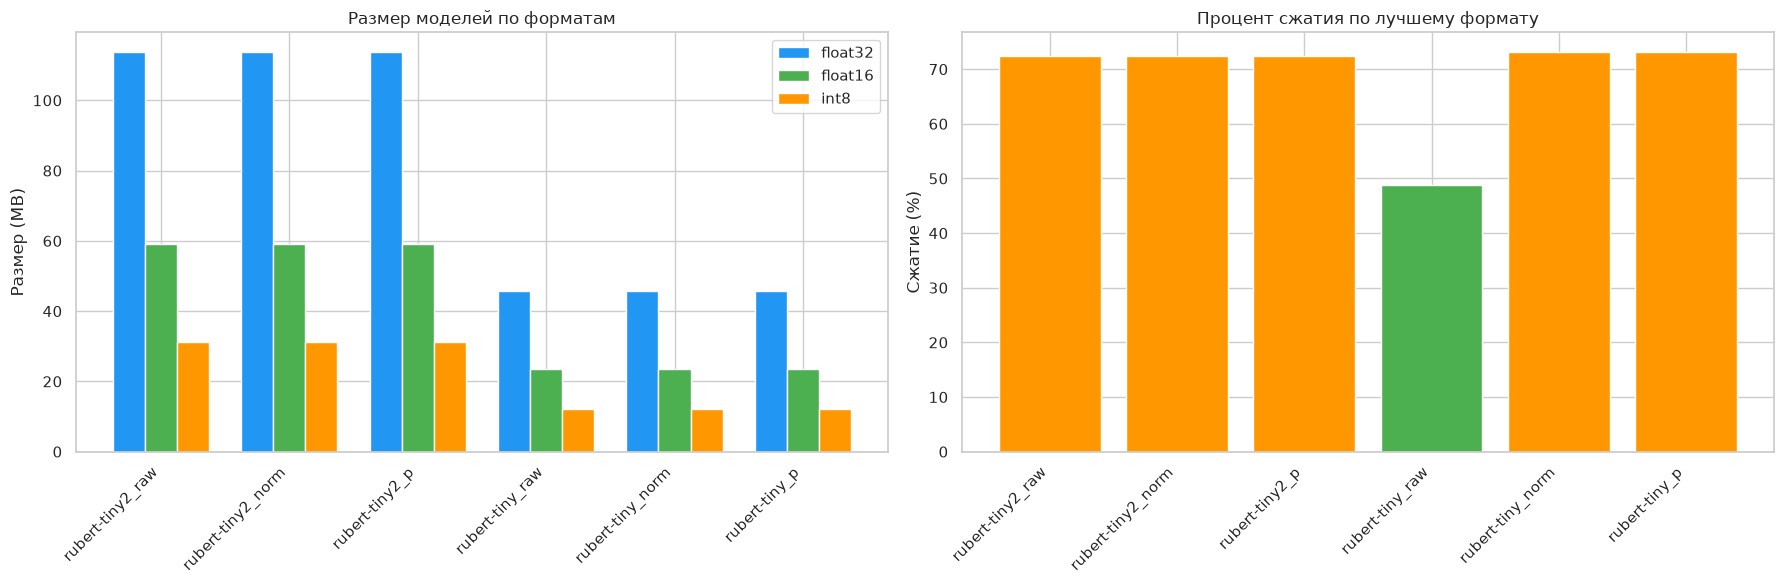

In [21]:
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plot_df = summary_df.copy()
plot_df['label'] = plot_df['model'] + '_' + plot_df['variant']

ax1 = axes[0]
x = range(len(plot_df))
width = 0.25
ax1.bar([i - width for i in x], plot_df['size_orig'] / 1024 ** 2, width, label='float32', color='#2196F3')
ax1.bar(x, plot_df['size_fp16'] / 1024 ** 2, width, label='float16', color='#4CAF50')
ax1.bar([i + width for i in x], plot_df['size_int8'] / 1024 ** 2, width, label='int8', color='#FF9800')
ax1.set_ylabel('Размер (MB)')
ax1.set_title('Размер моделей по форматам')
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df['label'], rotation=45, ha='right')
ax1.legend()

ax2 = axes[1]
colors = plot_df['best_format'].map({'int8': '#FF9800', 'float16': '#4CAF50', 'original': '#2196F3'})
ax2.bar(range(len(plot_df)), plot_df['reduction'] * 100, color=colors)
ax2.set_ylabel('Сжатие (%)')
ax2.set_title('Процент сжатия по лучшему формату')
ax2.set_xticks(range(len(plot_df)))
ax2.set_xticklabels(plot_df['label'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Дедупликация токенайзеров

Варианты одной архитектуры (raw, norm, p) используют одинаковые токенайзеры. Токенайзер сохраняется в одном месте, остальные заменяются на симлинки.

In [22]:
def file_hash(path):
    """Возвращает SHA256 хеш файла."""
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

In [23]:
tokenizer_files = ['tokenizer.json', 'tokenizer_config.json', 'vocab.txt', 'special_tokens_map.json']
dedup_saved = 0

for model_cfg in MODELS:
    prefix = model_cfg['save_prefix']
    variant_dirs = []
    for variant in TEXT_VARIANTS:
        for fmt in ['_fp16', '_onnx', '_int8', '']:
            if fmt:
                d = COMPRESSED_DIR / f'{prefix}_{variant}{fmt}'
            else:
                d = MODELS_DIR / f'{prefix}_{variant}'
            if d.exists():
                variant_dirs.append(d)

    if len(variant_dirs) < 2:
        continue

    for tf_name in tokenizer_files:
        ref_file = None
        ref_hash = None
        for d in variant_dirs:
            tf = d / tf_name
            if not tf.exists():
                continue
            if ref_file is None:
                ref_file = tf
                ref_hash = file_hash(tf)
            else:
                cur_hash = file_hash(tf)
                if cur_hash == ref_hash:
                    saved = tf.stat().st_size
                    tf.unlink()
                    os.symlink(ref_file, tf)
                    dedup_saved += saved

print(f'Дедупликация токенайзеров: сэкономлено {fmt_size(dedup_saved)}')

Дедупликация токенайзеров: сэкономлено 42.8 MB


## Итоговый отчёт

Суммарный размер моделей до и после сжатия.

In [24]:
total_orig = summary_df['size_orig'].sum()
total_fp16 = summary_df['size_fp16'].sum()
total_int8 = summary_df['size_int8'].sum()
total_best = summary_df['best_size'].sum()

print('Итоговый отчёт по сжатию моделей')
print()
print(f'Исходный размер (float32): {fmt_size(total_orig)}')
print(f'float16:                   {fmt_size(total_fp16)}')
print(f'ONNX int8:                 {fmt_size(total_int8)}')
print(f'Лучший вариант:            {fmt_size(total_best)}')
print()
print(f'Сжатие float16: {(1 - total_fp16 / total_orig) * 100:.1f}%')
print(f'Сжатие int8:    {(1 - total_int8 / total_orig) * 100:.1f}%')
print(f'Сжатие лучший:  {(1 - total_best / total_orig) * 100:.1f}%')
print()
print('Рекомендации по формату для каждой модели:')
for _, row in summary_df.iterrows():
    name = row['model'] + '_' + row['variant']
    fmt = row['best_format']
    size = row['best_size_h']
    reduction = row['reduction_h']
    print(f'  {name}: {fmt} ({size}, сжатие {reduction})')

Итоговый отчёт по сжатию моделей

Исходный размер (float32): 477.9 MB
float16:                   247.2 MB
ONNX int8:                 130.8 MB
Лучший вариант:            141.9 MB

Сжатие float16: 48.3%
Сжатие int8:    72.6%
Сжатие лучший:  70.3%

Рекомендации по формату для каждой модели:
  rubert-tiny2_raw: int8 (31.3 MB, сжатие 72.4%)
  rubert-tiny2_norm: int8 (31.3 MB, сжатие 72.4%)
  rubert-tiny2_p: int8 (31.3 MB, сжатие 72.4%)
  rubert-tiny_raw: float16 (23.4 MB, сжатие 48.7%)
  rubert-tiny_norm: int8 (12.3 MB, сжатие 73.1%)
  rubert-tiny_p: int8 (12.3 MB, сжатие 73.1%)


## Финальная таблица для развёртывания

Таблица с путями к лучшим версиям моделей для использования в продакшене.

In [25]:
deploy_rows = []

for _, row in summary_df.iterrows():
    prefix = row['prefix']
    variant = row['variant']
    fmt = row['best_format']

    if fmt == 'int8':
        path = COMPRESSED_DIR / f'{prefix}_{variant}_int8'
    elif fmt == 'float16':
        path = COMPRESSED_DIR / f'{prefix}_{variant}_fp16'
    else:
        path = MODELS_DIR / f'{prefix}_{variant}'

    deploy_rows.append({
        'model': row['model'],
        'variant': variant,
        'format': fmt,
        'path': str(path),
        'size': row['best_size_h'],
        'f1': row.get('f1_baseline', None),
    })

deploy_df = pd.DataFrame(deploy_rows)
deploy_df

,model,variant,format,path,size,f1
0,rubert-tiny2,raw,int8,/home/sophrosyne/STANKIN_AntiSpam_Bot/models/c...,31.3 MB,0.995651
1,rubert-tiny2,norm,int8,/home/sophrosyne/STANKIN_AntiSpam_Bot/models/c...,31.3 MB,0.999333
2,rubert-tiny2,p,int8,/home/sophrosyne/STANKIN_AntiSpam_Bot/models/c...,31.3 MB,0.998999
3,rubert-tiny,raw,float16,/home/sophrosyne/STANKIN_AntiSpam_Bot/models/c...,23.4 MB,0.995987
4,rubert-tiny,norm,int8,/home/sophrosyne/STANKIN_AntiSpam_Bot/models/c...,12.3 MB,0.999000
5,rubert-tiny,p,int8,/home/sophrosyne/STANKIN_AntiSpam_Bot/models/c...,12.3 MB,0.998999
